In [1]:
from modeller import *

env = Environ()
env.io.atom_files_directory = ['/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/']
env.io.hetatm = False
env.io.water = False

aln = Alignment(env)

# Sequence from PDB =
mdl = Model(env, file='3g45_nohetatm')
aln.append_model(mdl, align_codes='3g45_nohetatm', atom_files='3g45_nohetatm.pdb')

# Target sequence (without mutations WT) from .ali 
aln.append(file='structures.ali', align_codes='target')

# 2D alignment
aln.align2d(max_gap_length=50)

# Save
aln.write(file='structures_align2d.ali', alignment_format='PIR')
aln.write(file='structures_align2d.pap', alignment_format='PAP')  


                         MODELLER 10.8, 2025/11/04, r13157

     PROTEIN STRUCTURE MODELLING BY SATISFACTION OF SPATIAL RESTRAINTS


                     Copyright(c) 1989-2025 Andrej Sali
                            All Rights Reserved

                             Written by A. Sali
                               with help from
              B. Webb, M.S. Madhusudhan, M-Y. Shen, G.Q. Dong,
          M.A. Marti-Renom, N. Eswar, F. Alber, M. Topf, B. Oliva,
             A. Fiser, R. Sanchez, B. Yerkovich, A. Badretdinov,
                     F. Melo, J.P. Overington, E. Feyfant
                 University of California, San Francisco, USA
                    Rockefeller University, New York, USA
                      Harvard University, Cambridge, USA
                   Imperial Cancer Research Fund, London, UK
              Birkbeck College, University of London, London, UK


Kind, OS, HostName, Kernel, Processor: 4, Linux gbi017039525 6.8.0-110-generic x86_64
Date and time of compil

In [2]:
from modeller.automodel import *

# Residues to refine (modelled lr2)
# class MyModel(AutoModel):
#     def select_atoms(self):
#         return Selection(self.residue_range('282:A', '332:A'))

a = AutoModel(
    env,
    alnfile  = 'structures_align2d.ali',
    knowns   = '3g45_nohetatm',
    sequence = 'target'
    
)
 
a.starting_model = 1
a.ending_model   = 30          
a.md_level       = refine.very_slow 

a.make()


check_ali___> Checking the sequence-structure alignment. 

Implied intrachain target CA(i)-CA(i+1) distances longer than  8.0 angstroms:

ALN_POS  TMPL  RID1  RID2  NAM1  NAM2     DIST
----------------------------------------------
     76     1  281   323      N     T   49.947
END OF TABLE
read_to_681_> topology.submodel read from topology file:        3
mdtrsr__446W> A potential that relies on one protein is used, yet you have at
              least one known structure available. MDT, not library, potential is used.
0 atoms in HETATM/BLK residues constrained
to protein atoms within 2.30 angstroms
and protein CA atoms within 10.00 angstroms
0 atoms in residues without defined topology
constrained to be rigid bodies
condens_443_> Restraints marked for deletion were removed.
              Total number of restraints before, now:    41287    38334
iupac_m_397W> Atoms were not swapped because of the uncertainty of how to handle the H atom.
iupac_m_397W> Atoms were not swapped because of t

KeyboardInterrupt: 

In [9]:
from modeller import *
from modeller.scripts import complete_pdb
import glob
import os

log.verbose()
env = Environ()
env.libs.topology.read(file='$(LIB)/top_heav.lib')
env.libs.parameters.read(file='$(LIB)/par.lib')

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/remove_mutations_3g45'
modelling_dir = r'C:\Users\vitor\Documents\usp\usp-masters\6-preparation\protein\remove_mutations_3g45'
# Get files
model_files = sorted(
    glob.glob(os.path.join(modelling_dir, 'target.B9*.pdb'))
)

openf___224_> Open           $(LIB)/restyp.lib
openf___224_> Open           ${MODINSTALL10v7}/modlib/restyp_cif.lib
openf___224_> Open           ${MODINSTALL10v7}/modlib/resgrp.lib
rdresgr_266_> Number of residue groups:        2
openf___224_> Open           ${MODINSTALL10v7}/modlib/sstruc.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:       628888     614.148     0.600

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:       629416     614.664     0.600
openf___224_> Open           ${MODINSTALL10v7}/modlib/resdih.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,MiB]:       678016     662.125     0.647
rdrdih__263_> Number of dihedral angle types         :        9
              Maximal number of dihedral angle optima:        3
              Dihedral angle names                   :  Alph Phi Psi Omeg chi1 chi2 chi3 chi4 chi5
openf___224_> Open           ${MODINSTALL10v7}/modlib/radii.lib

Dynamically allocated memory at   amaxlibraries [B,KiB,Mi

In [10]:
len(model_files)

30

In [11]:
scores = []



# Save scores and profiles
for model_path in model_files:
    base_name = os.path.splitext(os.path.basename(model_path))[0]
    profile_file = os.path.join(modelling_dir, f'{base_name}.profile')
       
    mdl = complete_pdb(env, model_path)
    s = Selection(mdl)
    
    score = s.assess_dope()
    scores.append((score, base_name, profile_file))
    
    # s.assess_dope(output='ENERGY_PROFILE NO_REPORT',
    #               file=profile_file,
    #               normalize_profile=True,
    #               smoothing_window=15)

openf___224_> Open           C:\Users\vitor\Documents\usp\usp-masters\6-preparation\protein\remove_mutations_3g45\target.B99990001.pdb
readlinef__W> File: C:\Users\vitor\Documents\usp\usp-masters\6-preparation\protein\remove_mutations_3g45\target.B99990001.pdb, Line: 6
              Modeller will only read the first 80 characters of this line.


Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       445487     435.046     0.425

Dynamically allocated memory at    amaxsequence [B,KiB,MiB]:       445563     435.120     0.425

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       445734     435.287     0.425

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       446584     436.117     0.426

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       447842     437.346     0.427

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       449746     439.205     0.429

Dynamically allocated memory at amaxcoordinates [B,KiB,MiB]:       452

In [8]:
scores

[]

In [12]:

# Ranking final
print("\n Ranking - DOPE score")
for score, name, profile in sorted(scores[1:50]):
    print(f"  {name:40s}  DOPE: {score:.2f}")

best = sorted(scores)[0]
print(f"\nBest: {best[1]}  (DOPE: {best[0]:.2f})")



 Ranking - DOPE score
  target.B99990005                          DOPE: -49121.77
  target.B99990004                          DOPE: -48760.21
  target.B99990018                          DOPE: -48681.55
  target.B99990026                          DOPE: -48671.43
  target.B99990017                          DOPE: -48458.85
  target.B99990029                          DOPE: -48445.09
  target.B99990014                          DOPE: -48443.85
  target.B99990011                          DOPE: -48325.09
  target.B99990027                          DOPE: -48300.84
  target.B99990021                          DOPE: -48287.26
  target.B99990019                          DOPE: -48240.64
  target.B99990013                          DOPE: -48216.20
  target.B99990002                          DOPE: -48197.23
  target.B99990003                          DOPE: -48190.13
  target.B99990015                          DOPE: -48177.27
  target.B99990024                          DOPE: -48108.68
  target.B9999000

In [27]:
scores

[(-48450.359375,
  'target.B99990001',
  'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\6-preparation\\protein\\remove_mutations_3g45\\target.B99990001.profile'),
 (-48197.234375,
  'target.B99990002',
  'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\6-preparation\\protein\\remove_mutations_3g45\\target.B99990002.profile'),
 (-48190.12890625,
  'target.B99990003',
  'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\6-preparation\\protein\\remove_mutations_3g45\\target.B99990003.profile'),
 (-48760.20703125,
  'target.B99990004',
  'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\6-preparation\\protein\\remove_mutations_3g45\\target.B99990004.profile'),
 (-49121.76953125,
  'target.B99990005',
  'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\6-preparation\\protein\\remove_mutations_3g45\\target.B99990005.profile'),
 (-47895.38671875,
  'target.B99990006',
  'C:\\Users\\vitor\\Documents\\usp\\usp-masters\\6-preparation\\protein\\remove_mutations_3g45\\target.B99990006.profile'),
 (-47537

In [32]:
for score, file, path in sorted(scores)[:10]:
    print(score, file)

-49121.76953125 target.B99990005
-48760.20703125 target.B99990004
-48681.5546875 target.B99990018
-48671.43359375 target.B99990026
-48458.84765625 target.B99990017
-48450.359375 target.B99990001
-48445.08984375 target.B99990029
-48443.84765625 target.B99990014
-48325.0859375 target.B99990011
-48300.84375 target.B99990027


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import re
import numpy as np

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/remove_mutations_3g45'
modelling_dir = r'C:\Users\vitor\Documents\usp\usp-masters\6-preparation\protein\remove_mutations_3g45'
profiles_with_sum = []
profile_files = sorted(glob.glob(os.path.join(modelling_dir, '*.profile')))
for profile_path in profile_files:
    total_sum = None
    with open(profile_path, 'r') as f:
        for line in f:
            match = re.search(r'The sum of all numbers in the file:\s+([-\d.]+)', line)
            if match:
                total_sum = float(match.group(1))
                break
    
    profiles_with_sum.append((profile_path, total_sum))

# Sort from smaller to bigger
profiles_with_sum.sort(key=lambda x: x[1], reverse=True)
top10 = profiles_with_sum[-10:]  # Last 1o (smaller values)

In [22]:
for path, score in top10:
    print(score, os.path.splitext(os.path.basename(path))[0])

-14.4196 target.B99990001
-14.4649 target.B99990005
-14.4801 target.B99990004
-14.4844 target.B99990011
-14.4922 target.B99990021
-14.4983 target.B99990013
-14.5035 target.B99990026
-14.5091 target.B99990008
-14.5329 target.B99990002
-14.5652 target.B99990014


14, 5, 4, 26, 11

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
C:\Users\vitor\AppData\Local\Temp\ipykernel_19912\1124493357.py:13: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)


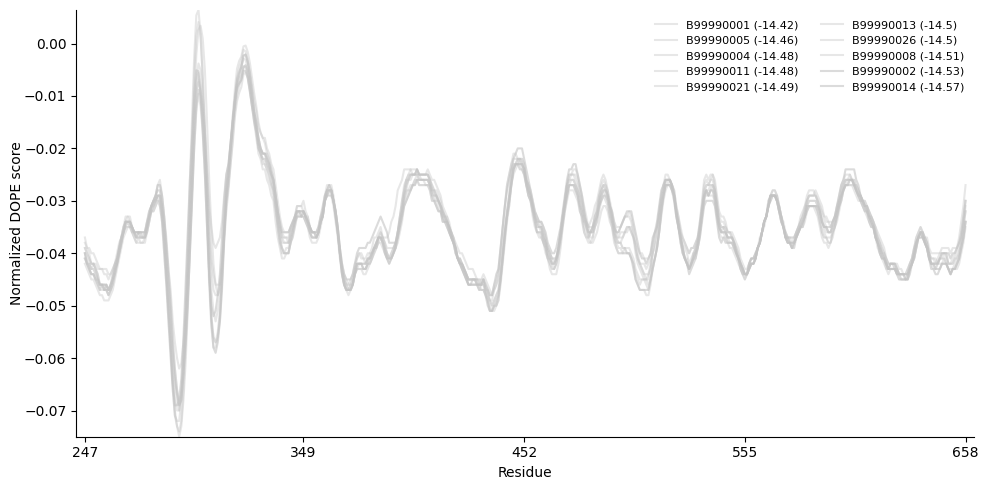

In [15]:

cinza = "#c4c4c4"
verde = '#6FAF9C'
roxo = '#A665B5'
# colors = [cinza] * 8 + [verde] * 2
colors = [cinza] *10

plt.figure(figsize=(10, 5))

all_dope = []
for i, (profile_path, total_sum) in enumerate(top10):

    name = os.path.basename(profile_path).replace('.profile', '').replace('target.', '')
    df = pd.read_csv(profile_path, sep='\s+', comment='#', header=None)
    residues = df[0] + 246
    dope=df[df.columns[-1]]
    all_dope.extend(dope.tolist())
    label = f'{name} ({round(total_sum, 2)})'    

    if i == 9 or i == 8:
        alpha = 0.6
    else:
        alpha = 0.4

    plt.plot(residues, dope, label=label, color=colors[i], alpha=alpha, )

# Scaling
plt.ylim(min(all_dope), max(all_dope))

plt.xlabel('Residue')
plt.ylabel('Normalized DOPE score', labelpad=0)

plt.title('')
plt.legend(fontsize=8,frameon=False, ncol=2)
ax = plt.gca()
plt.margins(x=0.01)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

first = residues.iloc[0]
last = residues.iloc[-1]
ticks = [first] + list(np.linspace(first, last, 5).astype(int)[1:-1]) + [last]
ax.set_xticks(ticks)
ax.set_xticklabels(ticks)

plt.tight_layout()
#plt.savefig(os.path.join(modelling_dir, 'dope_profiles.png'), dpi=150)
plt.show() 

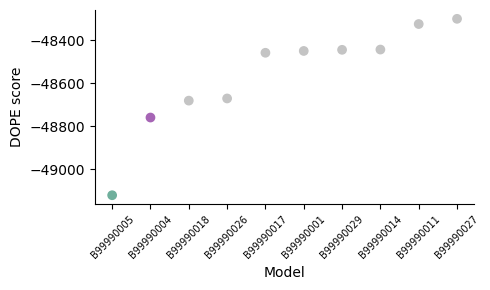

In [13]:
import matplotlib.pyplot as plt

# Ordenar do pior para o melhor (melhor fica à direita)
scores_sorted = sorted(scores, key=lambda x: x[0], reverse=False)
top10_scores = scores_sorted[:10]

names = [s[1].replace('target.', '').replace('.pdb', '') for s in top10_scores]

dopes = [s[0] for s in top10_scores]

# Destacar o melhor (último)
colors = [verde] + [roxo] + [cinza] * 8

fig, ax = plt.subplots(figsize=(5, 3))
ax.scatter(range(len(top10_scores)), dopes, color=colors, zorder=3)

ax.set_xlabel('Model')
ax.set_ylabel('DOPE score')
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, fontsize=7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig(os.path.join(modelling_dir, 'dope_total.png'), dpi=150)
plt.show()

In [44]:
def renumber_pdb(input_pdb, output_pdb, start):
    with open(input_pdb, 'r') as f:
        lines = f.readlines()
    
    current_resnum = None
    new_resnum = start - 1
    
    with open(output_pdb, 'w') as out:
        for line in lines:
            if line.startswith(('ATOM', 'HETATM')):
                res = line[22:26].strip()
                if res != current_resnum:
                    current_resnum = res
                    new_resnum += 1
                line = line[:22] + f'{new_resnum:4d}' + line[26:]
            out.write(line)

modelling_dir = '/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/'

In [45]:
renumber_pdb(
        input_pdb="/home/gbiuser/Documents/vitoria/usp-masters/6-preparation/protein/again/modeller_join/target.B99990042.pdb",
        output_pdb=modelling_dir + f"modelo_42.pdb",
        start=216
    )

In [ ]:
env = environ()
aln = alignment(env)
mdl = model(env, file='template')
aln.append_model(mdl, align_codes='template', atom_files='template.pdb')
aln.append(file='target.ali', align_codes='target')
aln.align2d()  # alinhamento baseado em estrutura, melhor que align()
aln.write(file='aln_refined.ali')